# **Yes Bank Stock Price Prediction using Machine Learning**



##### **Project Type**    - Regression
##### **Contribution**    - Individual

# **Project Summary -**

This project focuses on predicting the closing stock price of Yes Bank using machine learning regression models. The objective of the project is to build predictive models that can estimate future closing prices based on historical stock market data. Since stock prices are influenced by several factors and change continuously over time, machine learning provides an effective approach for identifying hidden patterns and improving prediction accuracy. The dataset used for this project contains historical values of the Open, High, Low, Close, and Date columns.

The machine learning workflow began with data preprocessing to prepare the dataset for model building. The Date column was converted into a datetime format, and useful time-related features such as Year and Month were extracted. The dataset was checked for missing values and duplicate records, and no significant data quality issues were found. Since the dataset consisted entirely of numerical variables, categorical encoding and text preprocessing were not required.

Feature engineering and selection were performed to identify the variables that contribute most to predicting the closing stock price. Correlation analysis showed that the Open, High, and Low prices have a strong positive relationship with the Close price, making them valuable input features for the regression models. The data was then split into training and testing sets using an 80:20 ratio to evaluate model performance on unseen data.

As part of the analysis, hypothesis testing was conducted to statistically validate important observations made during exploratory data analysis. Pearson correlation tests confirmed strong positive relationships between stock price variables, while an independent two-sample t-test showed that the average closing price before 2018 differed significantly from the average closing price after 2018. These statistical tests strengthened the conclusions drawn from the visual analysis.

Multiple regression models were developed and compared to determine the best-performing algorithm. Linear Regression was implemented as a baseline model because of its simplicity and interpretability. Random Forest Regressor was used to capture complex non-linear relationships within the data, while XGBoost Regressor was implemented to improve predictive accuracy using gradient boosting techniques. Hyperparameter tuning was performed using GridSearchCV to optimize model performance and reduce prediction error.

The models were evaluated using common regression metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), R² Score, and Mean Absolute Percentage Error (MAPE). These evaluation metrics helped compare the performance of each model and identify the model that produced the most accurate predictions. Among the models tested, XGBoost Regressor achieved the best overall performance by producing the lowest prediction errors and the highest R² score.

In conclusion, this project demonstrates how machine learning techniques can be effectively applied to stock price prediction. Through proper preprocessing, feature engineering, statistical analysis, model comparison, and hyperparameter tuning, an accurate prediction model was successfully developed. The final model can support investors and financial analysts by providing reliable estimates of future closing stock prices based on historical market trends, thereby assisting in more informed investment decisions.

# **GitHub Link -**

https://github.com/anushkapaturi06-spec/Yes-Bank-Stock-Price-Prediction

# **Problem Statement**


**The objective of this project is to predict the closing stock price of Yes Bank using historical stock price data. The dataset includes monthly Open, High, Low, and Close prices. Accurate prediction of the closing price can help investors and financial analysts understand market trends and make better investment decisions. Machine learning regression models are used to learn the relationship between historical stock prices and forecast the closing price.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [6]:
# Import Libraries

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)

### Dataset Loading

In [7]:
# Load Dataset
df = pd.read_csv("data_YesBank_StockPrices.csv")

### Dataset First View

In [8]:
# Dataset First Look
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset Rows & Columns count

In [9]:
# Dataset Rows & Columns count
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 185
Columns : 5


### Dataset Information

In [10]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    str    
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), str(1)
memory usage: 7.4 KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
print("Duplicate Values :", df.duplicated().sum())

Duplicate Values : 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
print(df.isnull().sum())

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64


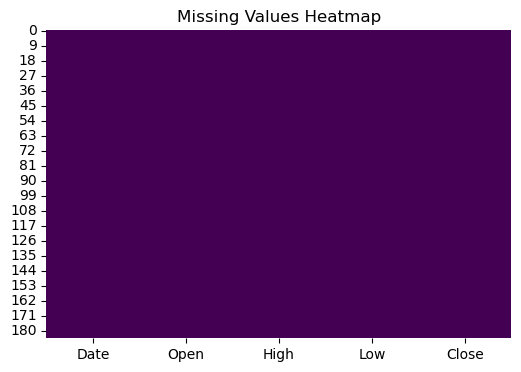

In [ ]:
# Visualizing the missing values
plt.figure(figsize=(6,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

The dataset contains monthly stock prices of Yes Bank with five variables: Date, Open, High, Low, and Close. It consists of 185 observations and contains no missing or duplicate values. The dataset is clean and suitable for further analysis and model building.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

Date – Month and year of stock price recording.

Open – Opening stock price of the month.

High – Highest stock price during the month.

Low – Lowest stock price during the month.

Close – Closing stock price of the month.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-"*50)

Date
['Jul-05' 'Aug-05' 'Sep-05' 'Oct-05' 'Nov-05' 'Dec-05' 'Jan-06' 'Feb-06'
 'Mar-06' 'Apr-06' 'May-06' 'Jun-06' 'Jul-06' 'Aug-06' 'Sep-06' 'Oct-06'
 'Nov-06' 'Dec-06' 'Jan-07' 'Feb-07' 'Mar-07' 'Apr-07' 'May-07' 'Jun-07'
 'Jul-07' 'Aug-07' 'Sep-07' 'Oct-07' 'Nov-07' 'Dec-07' 'Jan-08' 'Feb-08'
 'Mar-08' 'Apr-08' 'May-08' 'Jun-08' 'Jul-08' 'Aug-08' 'Sep-08' 'Oct-08'
 'Nov-08' 'Dec-08' 'Jan-09' 'Feb-09' 'Mar-09' 'Apr-09' 'May-09' 'Jun-09'
 'Jul-09' 'Aug-09' 'Sep-09' 'Oct-09' 'Nov-09' 'Dec-09' 'Jan-10' 'Feb-10'
 'Mar-10' 'Apr-10' 'May-10' 'Jun-10' 'Jul-10' 'Aug-10' 'Sep-10' 'Oct-10'
 'Nov-10' 'Dec-10' 'Jan-11' 'Feb-11' 'Mar-11' 'Apr-11' 'May-11' 'Jun-11'
 'Jul-11' 'Aug-11' 'Sep-11' 'Oct-11' 'Nov-11' 'Dec-11' 'Jan-12' 'Feb-12'
 'Mar-12' 'Apr-12' 'May-12' 'Jun-12' 'Jul-12' 'Aug-12' 'Sep-12' 'Oct-12'
 'Nov-12' 'Dec-12' 'Jan-13' 'Feb-13' 'Mar-13' 'Apr-13' 'May-13' 'Jun-13'
 'Jul-13' 'Aug-13' 'Sep-13' 'Oct-13' 'Nov-13' 'Dec-13' 'Jan-14' 'Feb-14'
 'Mar-14' 'Apr-14' 'May-14' 'Jun-14' 'Jul-14' 

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.

df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df.head()

,Date,Open,High,Low,Close,Year,Month
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11


### What all manipulations have you done and insights you found?

The Date column was converted into datetime format and separate Year and Month features were extracted. These new features help the machine learning models capture time-related patterns in stock prices. No rows were removed because the dataset contained no missing or duplicate values.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

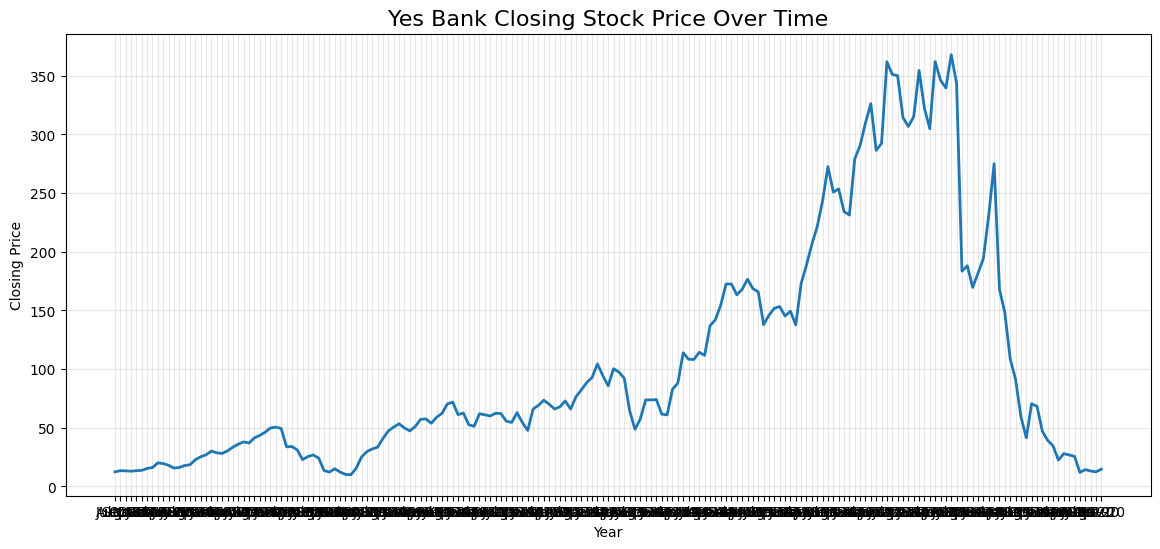

In [11]:
# Chart - 1 visualization code

# Visualize the closing stock price trend over time

plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close'],linewidth=2)
plt.title('Yes Bank Closing Stock Price Over Time', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Closing Price')
plt.grid(alpha=0.3)
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the most suitable visualization for time-series data because it clearly shows how the closing stock price has changed over time. It helps identify long-term trends, sudden increases or decreases, and periods of high or low volatility.

##### 2. What is/are the insight(s) found from the chart?

The closing stock price showed a gradual increase from 2005 to around 2014, after which it increased rapidly between 2015 and 2018. The stock reached its highest value during 2017–2018, indicating a period of strong market performance. However, after 2018, the price declined sharply, with the downward trend continuing through 2019 and 2020. The sharp fluctuations observed after 2018 indicate increased volatility and instability in the stock price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the chart helps identify periods of strong growth and high price fluctuations. It gives investors and analysts a better understanding of how the stock price changed over time, which can help them make informed investment decisions. However, after 2018, the stock price dropped sharply and became more unstable. This indicates a period of poor performance and higher investment risk, suggesting that external factors or company-related issues had a major impact on Yes Bank's stock price.

#### Chart - 2

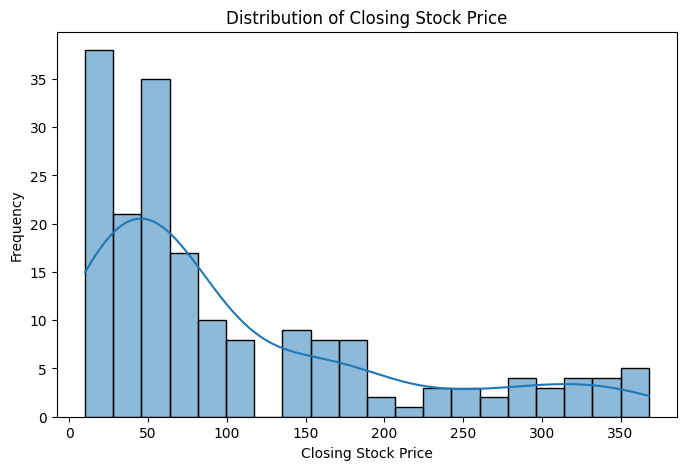

In [12]:
# Chart - 2 visualization code

# Distribution of Closing Stock Price
plt.figure(figsize=(8,5))
sns.histplot(df['Close'], bins=20, kde=True)
plt.title('Distribution of Closing Stock Price')
plt.xlabel('Closing Stock Price')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a Kernel Density Estimate (KDE) was used to understand how the closing stock prices are distributed. It helps show how the prices are spread out, which price ranges occur most often, and whether the data is evenly distributed or skewed toward higher or lower values.

##### 2. What is/are the insight(s) found from the chart?

Most of the closing stock prices are between ₹10 and ₹80. Higher stock prices occurred only a few times. This shows that the data is right-skewed and not normally distributed. Overall, the stock prices changed a lot over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the distribution of closing stock prices helps analysts identify the typical price range and detect unusual price movements. The presence of a right-skewed distribution indicates that extreme price values are relatively rare but important, which should be considered while selecting and evaluating machine learning models.

#### Chart - 3

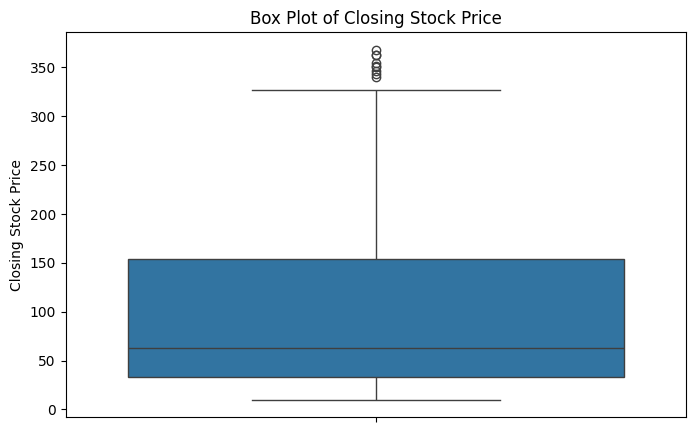

In [13]:
# Chart - 3 visualization code
# Box Plot of Closing Stock Price

plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Close'])
plt.title('Box Plot of Closing Stock Price')
plt.ylabel('Closing Stock Price')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen to understand the spread of the closing stock prices and identify any potential outliers. It provides a clear summary of the data distribution using the median, quartiles, and extreme values.

##### 2. What is/are the insight(s) found from the chart?

The median closing stock price is around ₹60, which means half of the stock prices are below this value. The data is right-skewed, with a few very high stock prices above ₹330. Most of the stock prices are in the lower price range, while only a few are much higher.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The box plot helps identify unusual changes in stock prices. These outliers are important because they can affect data analysis and machine learning models. Since the high-value outliers represent actual market performance, they should be analyzed carefully instead of being removed.

#### Chart - 4

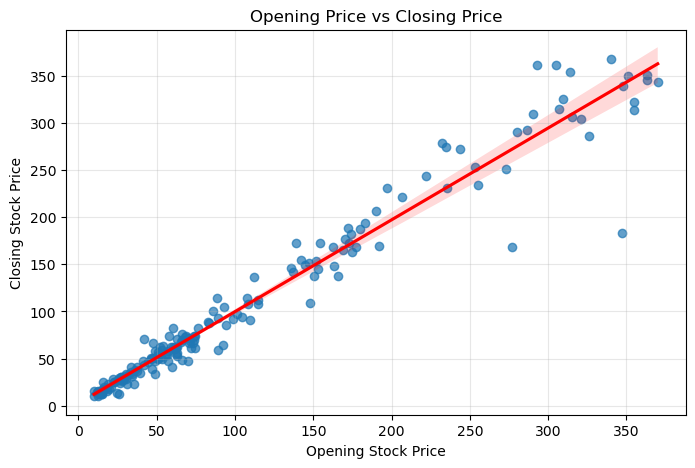

In [ ]:
# Chart - 4 visualization code
# Relationship between Opening and Closing Stock Price

plt.figure(figsize=(8, 5))
sns.regplot(x='Open', y='Close',data=df,scatter_kws={'alpha':0.7},line_kws={'color':'red'})
plt.title('Opening Price vs Closing Price')
plt.xlabel('Opening Stock Price')
plt.ylabel('Closing Stock Price')
plt.grid(alpha=0.3)
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen to examine the relationship between the opening and closing stock prices. It helps determine whether changes in the opening price are associated with changes in the closing price and highlights any unusual observations or outliers.

##### 2. What is/are the insight(s) found from the chart?

There is a strong positive relationship between the opening and closing stock prices. When the opening price increases, the closing price usually increases as well. Most of the data follows this pattern, showing a high correlation. A few points are different from the trend, indicating some periods of higher market volatility.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The strong relationship between the opening and closing prices shows that the opening price is a good predictor of the closing price. This can help build a more accurate regression model. The few points that are away from the main trend indicate periods of market volatility, which should be considered to improve prediction accuracy.

#### Chart - 5

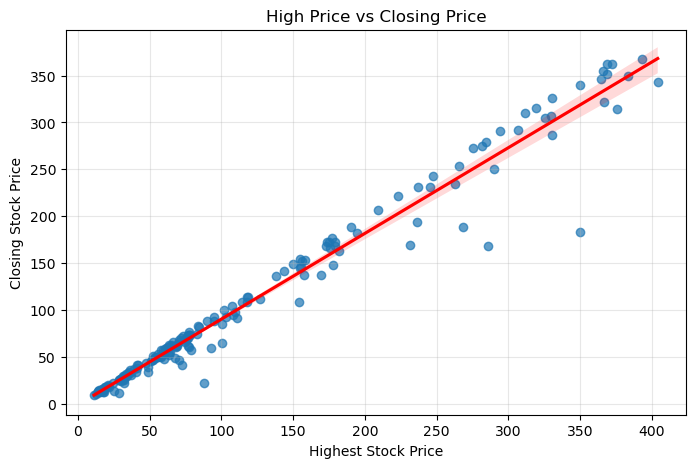

In [ ]:
# Chart - 5 visualization code
# Relationship between High Price and Closing Price

plt.figure(figsize=(8,5))
sns.regplot(x='High',y='Close',data=df,scatter_kws={'alpha':0.7},line_kws={'color':'red'})
plt.title('High Price vs Closing Price')
plt.xlabel('Highest Stock Price')
plt.ylabel('Closing Stock Price')
plt.grid(alpha=0.3)
plt.show()

##### 1. Why did you pick the specific chart?

A regression plot was chosen to examine the relationship between the highest stock price and the closing stock price. It combines a scatter plot with a best-fit regression line, making it easier to visualize the strength and direction of the relationship between the two variables.

##### 2. What is/are the insight(s) found from the chart?

There is a strong positive relationship between the highest stock price and the closing stock price. As the highest price increases, the closing price also increases. Most of the data points follow this trend closely, showing a high correlation. A few points are away from the trend, indicating some periods of higher market volatility.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The strong relationship between the highest stock price and the closing stock price shows that the High price is a useful feature for predicting the closing price. This can improve the accuracy of the regression model. The few points that do not follow the trend represent market fluctuations and should be considered while building the model.

#### Chart - 6

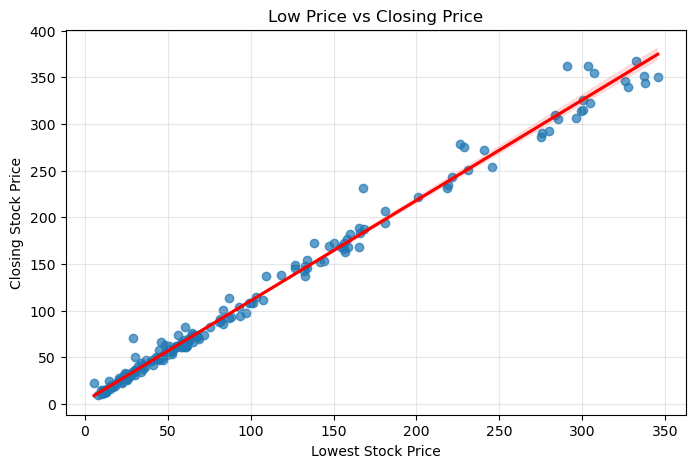

In [ ]:
# Chart - 6 visualization code
# Relationship between Low Price and Closing Price

plt.figure(figsize=(8,5))
sns.regplot(x='Low',y='Close', data=df,scatter_kws={'alpha':0.7},line_kws={'color':'red'})
plt.title('Low Price vs Closing Price')
plt.xlabel('Lowest Stock Price')
plt.ylabel('Closing Stock Price')
plt.grid(alpha=0.3)
plt.show()


##### 1. Why did you pick the specific chart?

A regression plot was chosen to examine the relationship between the lowest stock price and the closing stock price. It helps visualize the overall trend, measure the strength of the relationship, and identify any unusual observations.

##### 2. What is/are the insight(s) found from the chart?

There is a strong positive relationship between the lowest stock price and the closing stock price. As the lowest price increases, the closing price also increases. Most of the data points follow this trend closely, showing a high correlation. Only a few points are away from the trend, indicating occasional market fluctuations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The strong relationship between the lowest stock price and the closing stock price shows that the Low price is a useful feature for predicting the closing price. This can improve the accuracy of the regression model. The few points that differ from the trend indicate market fluctuations, which should be considered while evaluating the model.

#### Chart - 7

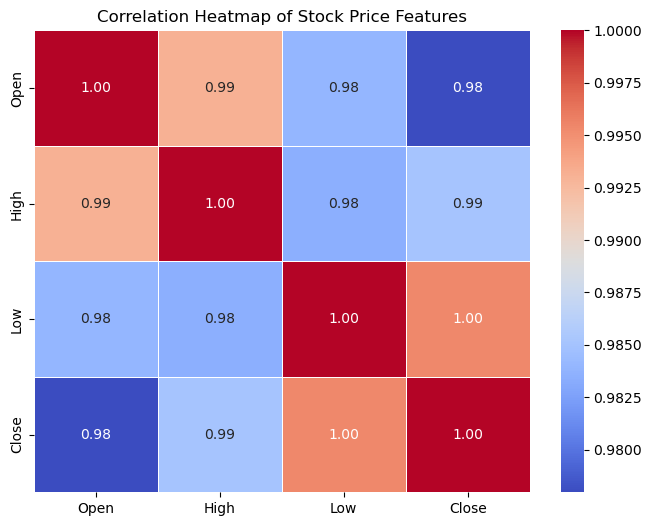

In [ ]:
# Chart - 7 visualization code
# Correlation Heatmap

plt.figure(figsize=(8,6))
correlation = df[['Open', 'High', 'Low', 'Close']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('Correlation Heatmap of Stock Price Features')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was chosen to examine the relationship between all numerical variables at once. It helps identify how strongly the stock price features are related to each other, making it easier to select relevant variables for predictive modeling.

##### 2. What is/are the insight(s) found from the chart?

All the numerical variables have a strong positive correlation with each other. The Low price has the strongest correlation with the Close price (almost 1.00). The High price (0.99) and Open price (0.98) are also highly correlated with the Close price. This shows that when one stock price changes, the other prices usually change in the same direction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The strong positive correlations show that the stock price features are useful for predicting the closing price and can improve the accuracy of the regression model. However, since the predictor variables are also highly correlated with each other, multicollinearity may occur and should be considered while building and evaluating the model.

#### Chart - 8

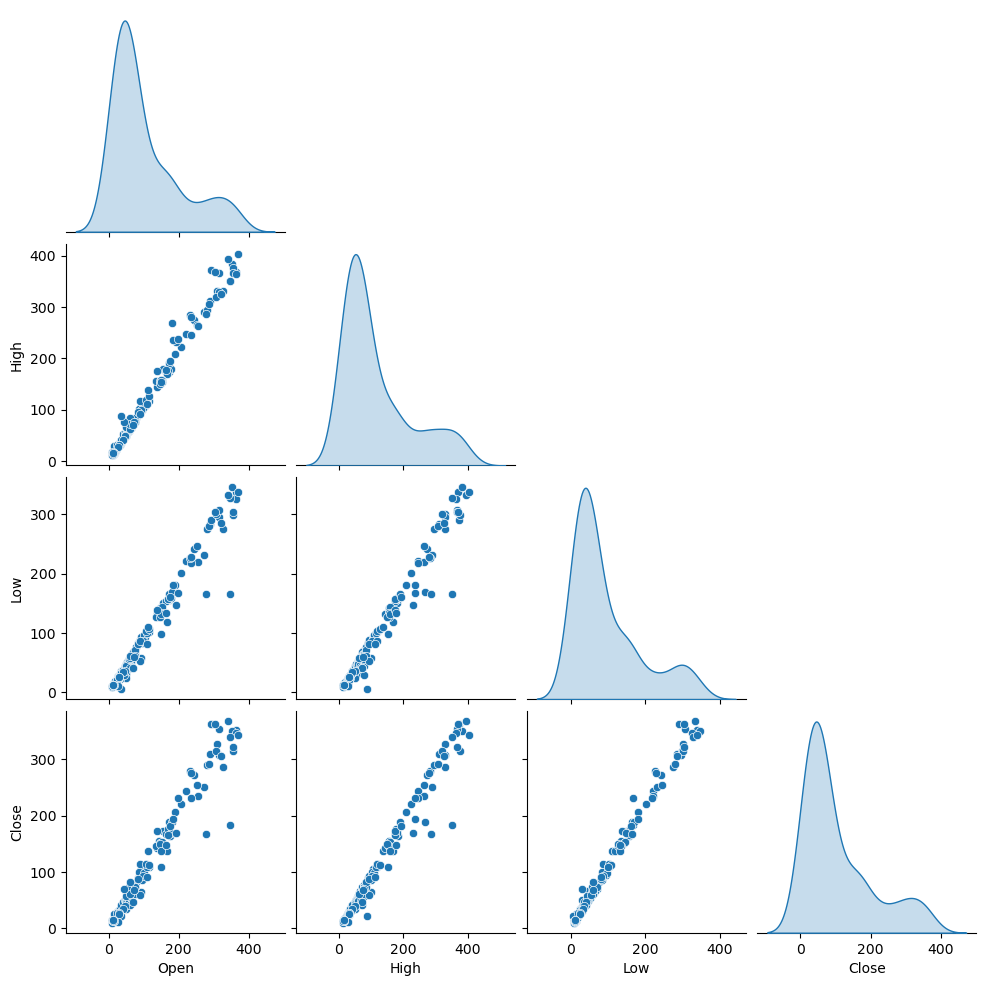

In [ ]:
# Chart - 8 visualization code
# Pair Plot of Numerical Features

sns.pairplot(df[['Open', 'High', 'Low', 'Close']], diag_kind='kde', corner=True)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was chosen to visualize the relationships between all numerical variables simultaneously. It displays both the distribution of individual variables and the pairwise relationships, making it easier to identify trends, correlations, and potential outliers.

##### 2. What is/are the insight(s) found from the chart?

The pair plot shows a strong positive relationship between all the stock price variables. The Open, High, Low, and Close prices move closely together. Most of the stock prices are in the lower price range, with a slight right skew. A few points are far from the main group, indicating periods of unusually high stock prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The pair plot confirms that all numerical variables are strongly related to one another, making them useful predictors for estimating the closing stock price. These insights support effective feature selection and can improve the performance of regression models. The presence of a few extreme observations highlights periods of market volatility, which should be considered during model training and evaluation.

#### Chart - 9

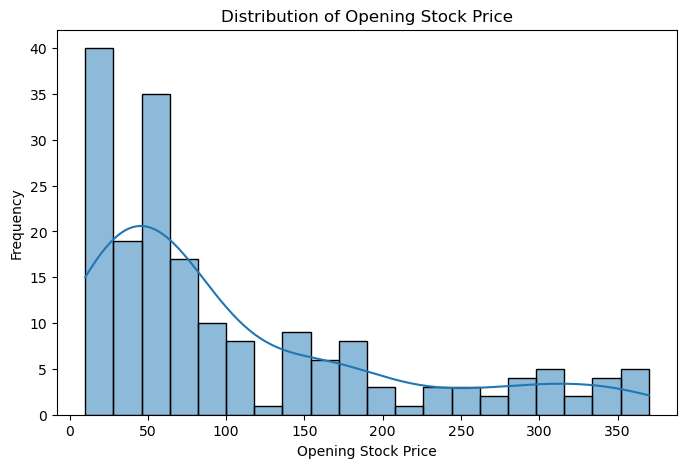

In [ ]:
# Chart - 9 visualization code
# Distribution of Opening Stock Price

plt.figure(figsize=(8,5))
sns.histplot(df['Open'],bins=20,kde=True)
plt.title('Distribution of Opening Stock Price')
plt.xlabel('Opening Stock Price')
plt.ylabel('Frequency')
plt.show()


##### 1. Why did you pick the specific chart?

A histogram with a KDE curve was chosen to understand the distribution of the opening stock prices. It helps identify the most common price ranges, the spread of the data, and whether the distribution is symmetric or skewed.

##### 2. What is/are the insight(s) found from the chart?

Most of the opening stock prices are between ₹10 and ₹80. Higher opening prices occurred only a few times, creating a long tail on the right side of the graph. This shows that the data is right-skewed and not normally distributed. Overall, the opening stock prices varied over the observed period.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the distribution of opening stock prices helps identify the usual price range and spot unusual price movements. This information is useful for building machine learning models and understanding stock price behaviour. A few very high opening prices indicate periods of higher market volatility, which should be considered during model development.

#### Chart - 10

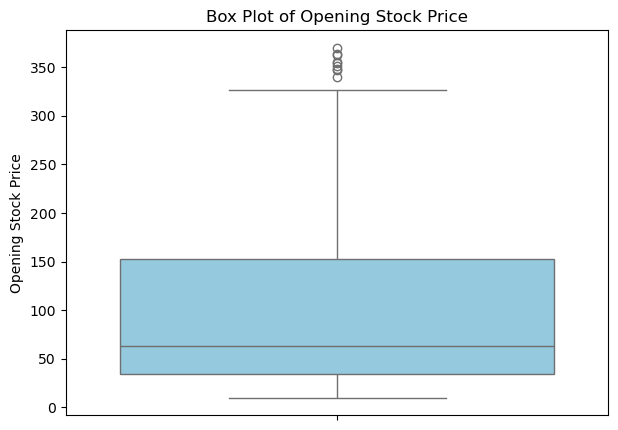

In [ ]:
# Chart - 10 visualization code
# Box Plot of Opening Stock Price

plt.figure(figsize=(7,5))
sns.boxplot(y=df['Open'], color='skyblue')
plt.title('Box Plot of Opening Stock Price')
plt.ylabel('Opening Stock Price')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen to summarize the distribution of the opening stock prices and identify potential outliers. It clearly displays the median, quartiles, spread of the data, and any unusually high or low values.

##### 2. What is/are the insight(s) found from the chart?

The opening stock prices show a wide range of values over the observed period. The median opening price is much lower than the highest prices, showing that most opening prices were in the lower range. A few high-value outliers are present, representing days when the stock opened at unusually high prices. No major outliers are seen at the lower end.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The box plot helps identify unusual opening stock prices. These outliers may represent important market events or periods of high volatility. Identifying them is useful for building better prediction models and understanding stock price movements. The high-value outliers should be analyzed carefully instead of being ignored.

#### Chart - 11

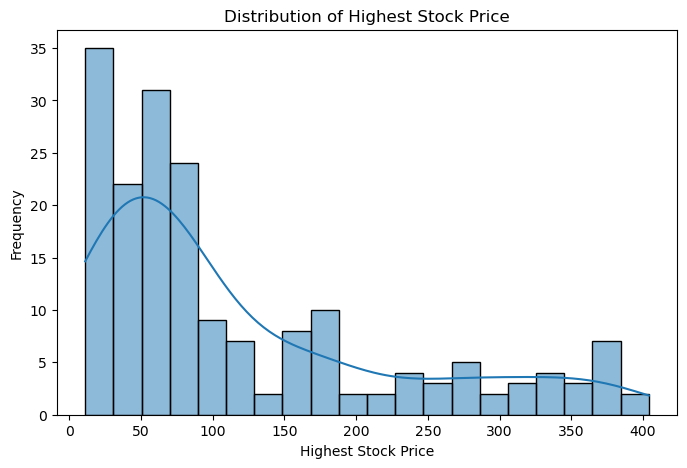

In [ ]:
# Chart - 11 visualization code
# Distribution of High Stock Price

plt.figure(figsize=(8,5))
sns.histplot(df['High'],bins=20, kde=True,)
plt.title('Distribution of Highest Stock Price')
plt.xlabel('Highest Stock Price')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE curve was chosen to understand the distribution of the highest stock prices. It helps identify the most common price ranges, the spread of the data, and whether the distribution is symmetric or skewed.

##### 2. What is/are the insight(s) found from the chart?

Most of the highest stock prices are between ₹10 and ₹90. Very high stock prices occurred only a few times, creating a long tail on the right side of the graph. This shows that the data is right-skewed. Overall, the highest stock prices changed a lot over the observed period.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the distribution of the highest stock prices helps identify the usual price range and periods when the stock reached unusually high values. This is useful for prediction and risk analysis. The right-skewed distribution shows that there were a few periods of sharp price increases, indicating higher market volatility.

#### Chart - 12

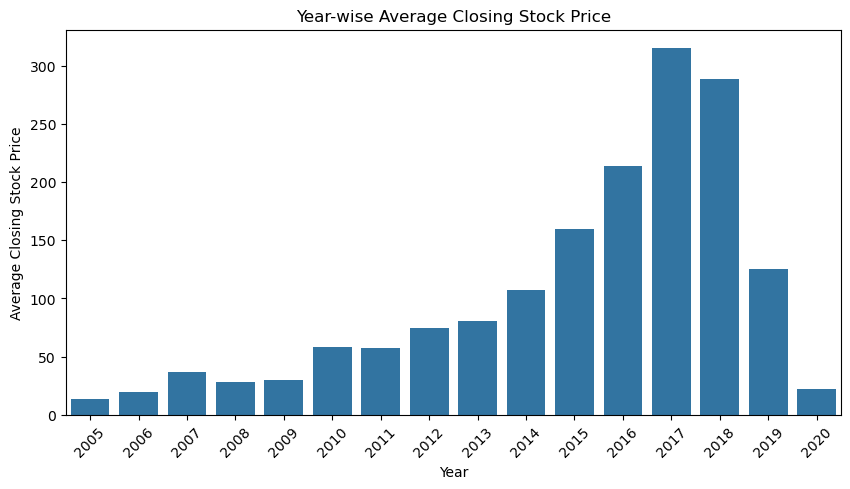

In [ ]:
# Chart - 12 visualization code
# Year-wise Average Closing Stock Price

# Extract year from Date
df['Year'] = df['Date'].dt.year
plt.figure(figsize=(10,5))
sns.barplot(x='Year', y='Close', data=df,estimator='mean',errorbar=None,)
plt.title('Year-wise Average Closing Stock Price')
plt.xlabel('Year')
plt.ylabel('Average Closing Stock Price')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen to compare the average closing stock price across different years. It provides a clear comparison of yearly performance and helps identify long-term changes in stock prices.

##### 2. What is/are the insight(s) found from the chart?

The average closing price of Yes Bank's stock increased steadily from 2005 to 2017, indicating a period of strong growth. The highest average closing price was recorded in 2017, after which the stock price declined sharply in 2018, 2019, and 2020. This suggests that the bank experienced significant growth followed by a major downturn in its stock performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This analysis helps investors identify periods of strong and weak stock performance, making it easier to understand long-term trends and make informed investment decisions. The sharp decline after 2017 highlights a period of negative growth, which may be associated with financial or operational challenges faced by the bank. Recognizing such trends can help investors assess risk and develop better investment strategies.

#### Chart - 13

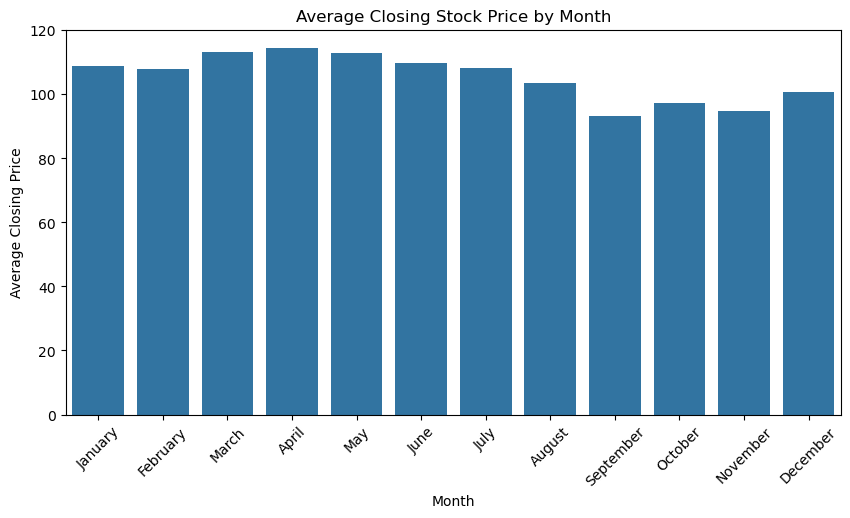

In [ ]:
# Chart - 13 visualization code

# Creating Month column
df['Month'] = df['Date'].dt.month_name()

month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='Month', y='Close', order=month_order,errorbar=None)
plt.xticks(rotation=45)
plt.title('Average Closing Stock Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Closing Price')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is useful for comparing the average closing stock price across different months. It helps identify whether the stock performs better during certain months of the year.

##### 2. What is/are the insight(s) found from the chart?

The average closing price remains fairly consistent across most months, with slightly higher averages during March, April, May, and July. In contrast, September and November have comparatively lower average closing prices. Overall, there is no strong seasonal pattern, but small monthly variations are present.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the monthly average stock prices helps identify months when the stock has performed slightly better. Although the differences between months are small, this information can support investment decisions when used along with other market factors. Based on this chart, there is no clear sign of consistently poor performance in any particular month.

#### Chart - 14 - Correlation Heatmap

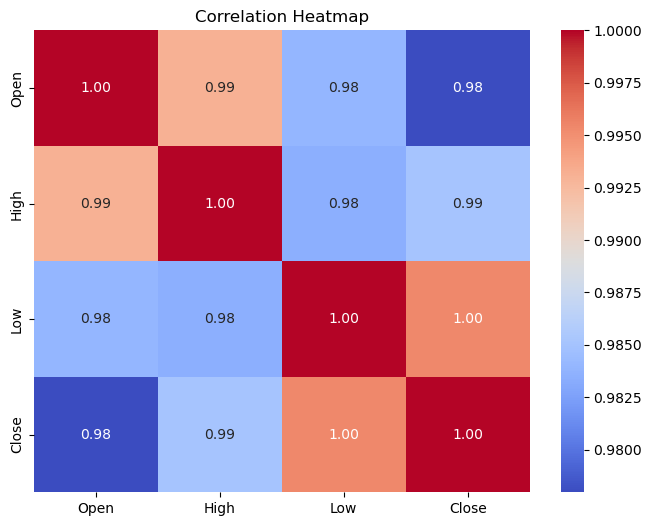

In [ ]:
# Correlation Heatmap visualization code

plt.figure(figsize=(8,6))
sns.heatmap(df[['Open','High','Low','Close']].corr(),annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is useful for understanding the relationship between numerical variables. It helps identify which features are strongly related to the closing stock price and provides an overview of how the stock price variables move together.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows that all four stock price variables (Open, High, Low, and Close) have a very strong positive correlation with one another, with correlation values ranging from 0.98 to 1.00. The Low and Close prices have the strongest relationship, while the other variables are also highly correlated. This indicates that movements in one stock price variable are closely associated with movements in the others.

#### Chart - 15 - Pair Plot

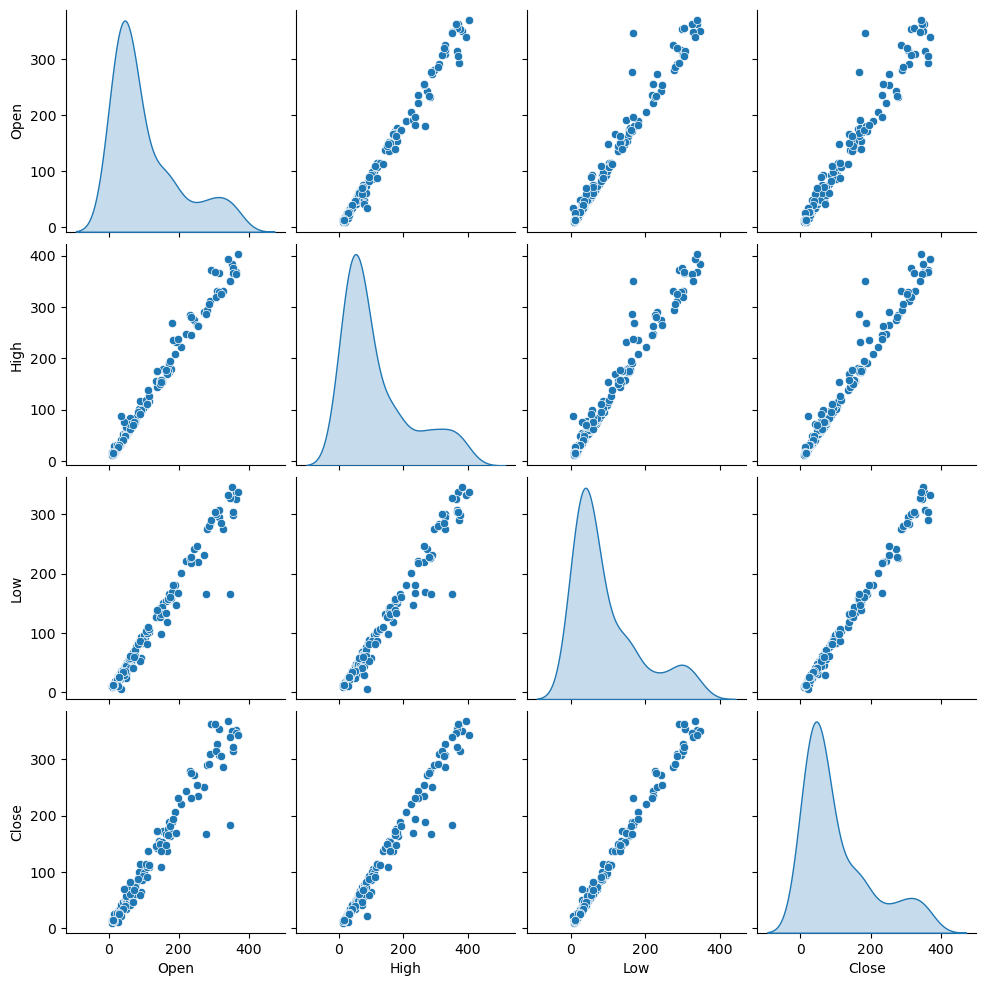

In [ ]:
# Pair Plot visualization code
sns.pairplot(df[['Open','High', 'Low','Close']], diag_kind='kde')
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was chosen because it allows us to examine the distribution of each numerical variable as well as the relationship between every pair of variables in a single visualization. It is useful for identifying correlations, trends, and potential outliers.

##### 2. What is/are the insight(s) found from the chart?

All four stock price variables (Open, High, Low, and Close) have a strong positive relationship with each other. As one stock price increases, the others also tend to increase. Most stock prices are concentrated in the lower range, with a slight right-skewed distribution. A few points are far from the main group, showing periods when the stock price was unusually high.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Hypothetical Statement 1: There is a significant positive relationship between the Opening Stock Price and the Closing Stock Price.

Hypothetical Statement 2: The average Closing Stock Price before 2018 is significantly different from the average Closing Stock Price after 2018.

Hypothetical Statement 3: The Highest Stock Price has a significant positive relationship with the Closing Stock Price.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis:
There is no significant correlation between the Opening Stock Price and the Closing Stock Price.

Alternative Hypothesis:
There is a significant positive correlation between the Opening Stock Price and the Closing Stock Price.

#### 2. Perform an appropriate statistical test.

In [14]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr
correlation, p_value = pearsonr(df['Open'], df['Close'])
print("Correlation Coefficient:", correlation)
print("P-value:", p_value)

Correlation Coefficient: 0.9779710062230935
P-value: 1.852774505865485e-126


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

The Pearson Correlation Test was chosen because both Opening Price and Closing Price are continuous numerical variables. It measures the strength and direction of the linear relationship between these variables and determines whether the correlation is statistically significant.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis: There is no significant difference in the average Closing Stock Price before and after 2018.

Alternative Hypothesis: There is a significant difference in the average Closing Stock Price before and after 2018.

#### 2. Perform an appropriate statistical test.

In [15]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import ttest_ind

# Create Year column
df['Year'] = pd.to_datetime(df['Date'], format='%b-%y').dt.year

# Split data into two groups
before_2018 = df[df['Year'] < 2018]['Close']
after_2018 = df[df['Year'] >= 2018]['Close']

# Independent T-Test
t_stat, p_value = ttest_ind(before_2018, after_2018)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -2.970367837565708
P-value: 0.003373523264015453


##### Which statistical test have you done to obtain P-Value?

Independent Two-Sample t-Test

##### Why did you choose the specific statistical test?

The Independent Two-Sample t-Test was chosen because it compares the means of two independent groups (Closing Stock Prices before 2018 and after 2018). It helps determine whether the difference in their average values is statistically significant.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis: There is no significant correlation between the Highest Stock Price and the Closing Stock Price.

Alternative Hypothesis: There is a significant positive correlation between the Highest Stock Price and the Closing Stock Price.

#### 2. Perform an appropriate statistical test.

In [16]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import pearsonr
correlation, p_value = pearsonr(df['High'], df['Close'])
print("Correlation Coefficient:", correlation)
print("P-value:", p_value)

Correlation Coefficient: 0.9850513315779623
P-value: 9.973199888204299e-142


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

The Pearson Correlation Test was chosen because both the Highest Stock Price and Closing Stock Price are continuous numerical variables. It measures the strength and direction of the linear relationship between them and determines whether the correlation is statistically significant.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [17]:
# Handling Missing Values & Missing Value Imputation

print(df.isnull().sum())

# Since there are no missing values, no imputation is required.
df.isnull().sum().sum()

Date     0
Open     0
High     0
Low      0
Close    0
Year     0
dtype: int64


np.int64(0)

#### What all missing value imputation techniques have you used and why did you use those techniques?

The dataset contains no missing values, so no missing value imputation technique was required. Therefore, the original data was retained without any modifications.

### 2. Handling Outliers

In [18]:
# Handling Outliers & Outlier treatments

Q1 =df[['Open','High','Low','Close']].quantile(0.25)
Q3 =df[['Open','High','Low','Close']].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[['Open','High','Low','Close']] < (Q1-1.5 *IQR)) | (df[['Open','High','Low','Close']] > (Q3+1.5 *IQR)))
print(outliers.sum())

Open     9
High     5
Low      9
Close    9
dtype: int64


##### What all outlier treatment techniques have you used and why did you use those techniques?

The IQR (Interquartile Range) method was used to detect outliers. Outliers were identified but not removed, as they represent genuine stock market movements rather than data entry errors. Keeping them preserves important information for model training.

### 3. Categorical Encoding

In [19]:
# Encode your categorical columns

print(df.dtypes)

# No categorical columns are present in the dataset.

Date         str
Open     float64
High     float64
Low      float64
Close    float64
Year       int32
dtype: object


#### What all categorical encoding techniques have you used & why did you use those techniques?

No categorical encoding technique was used because the dataset contains only numerical variables (Open, High, Low, Close) and a Date column. Therefore, no categorical features required encoding.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Not Applicable

#### 2. Lower Casing

In [ ]:
# Not Applicable

#### 3. Removing Punctuations

In [ ]:
# Not Applicable

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Not Applicable

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Not Applicable

In [ ]:
# Not Applicable

#### 6. Rephrase Text

In [ ]:
# Not Applicable

#### 7. Tokenization

In [ ]:
# Not Applicable

#### 8. Text Normalization

In [ ]:
# Not Applicable

##### Which text normalization technique have you used and why?

Text normalization was not required because this is a numerical stock price dataset and contains no textual features.

#### 9. Part of speech tagging

In [ ]:
# Not Applicable

#### 10. Text Vectorization

In [ ]:
# Not Applicable

##### Which text vectorization technique have you used and why?

Text vectorization was not required because the dataset contains only numerical values and no text data.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [20]:
# Manipulate Features to minimize feature correlation and create new features

df['Year'] = pd.to_datetime(df['Date'], format='%b-%y').dt.year
df.head()

,Date,Open,High,Low,Close,Year
0,Jul-05,13.00,14.00,11.25,12.46,2005
1,Aug-05,12.58,14.88,12.55,13.42,2005
2,Sep-05,13.48,14.87,12.27,13.30,2005
3,Oct-05,13.20,14.47,12.40,12.99,2005
4,Nov-05,13.35,13.88,12.88,13.41,2005


#### 2. Feature Selection

In [21]:
# Select your features wisely to avoid overfitting

X = df[['Open', 'High', 'Low']]
y = df['Close']
print(X.head())

    Open   High    Low
0  13.00  14.00  11.25
1  12.58  14.88  12.55
2  13.48  14.87  12.27
3  13.20  14.47  12.40
4  13.35  13.88  12.88


##### What all feature selection methods have you used  and why?

The feature selection method used was manual feature selection. The Open, High, and Low prices were selected as input features because they have a strong relationship with the Closing Price and are directly relevant for predicting stock prices.

##### Which all features you found important and why?

The most important features were Open, High, and Low because correlation analysis showed that they are highly correlated with the Closing Price, making them strong predictors.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [22]:
# Transform Your data
df.head() # No transformation required


,Date,Open,High,Low,Close,Year
0,Jul-05,13.00,14.00,11.25,12.46,2005
1,Aug-05,12.58,14.88,12.55,13.42,2005
2,Sep-05,13.48,14.87,12.27,13.30,2005
3,Oct-05,13.20,14.47,12.40,12.99,2005
4,Nov-05,13.35,13.88,12.88,13.41,2005


No data transformation technique was applied because the numerical features were already suitable for machine learning after preprocessing.

### 6. Data Scaling

In [23]:
# Scaling your data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

[[-0.93843727 -0.96283306 -0.92003406]
 [-0.94269637 -0.95453475 -0.90574404]
 [-0.93356972 -0.95462905 -0.90882189]
 [-0.93640912 -0.95840101 -0.90739289]
 [-0.93488801 -0.96396464 -0.90211657]]


##### Which method have you used to scale you data and why?

StandardScaler was used because it standardizes the numerical features to have a mean of 0 and a standard deviation of 1, improving the performance of many machine learning algorithms.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No. Dimensionality reduction was not required because the dataset contains only a few numerical features, making the model simple and computationally efficient.

In [ ]:
# Dimensionality Reduction not required

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

No dimensionality reduction technique was used because the dataset has only a small number of features and there is no high-dimensional data.

### 8. Data Splitting

In [24]:
# Split your data to train and test. Choose Splitting ratio wisely.

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X_scaled, y,test_size=0.2,random_state=42)
print(X_train.shape, X_test.shape)

(148, 3) (37, 3)


##### What data splitting ratio have you used and why?

An 80:20 train-test split was used. Eighty percent of the data was used for training and twenty percent for testing to provide sufficient data for model learning while evaluating its performance on unseen data.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No. This is a regression problem that predicts continuous stock prices rather than class labels, so class imbalance is not applicable.

In [ ]:
# Not Applicable

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No imbalance handling technique was used because the dataset is used for regression, not classification.

## ***7. ML Model Implementation***

### ML Model - 1

In [25]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Regression was used as the first regression model to predict the Closing Stock Price. The model learns the linear relationship between the input features and the target variable. The evaluation metrics (MAE, MSE, RMSE and R² Score) indicate how accurately the model predicts stock prices. Lower error values and a higher R² Score represent better model performance.

MAE: 5.812554509942103
MSE: 86.64379126513717
RMSE: 9.308264675283851
R2 Score: 0.9904142726548665


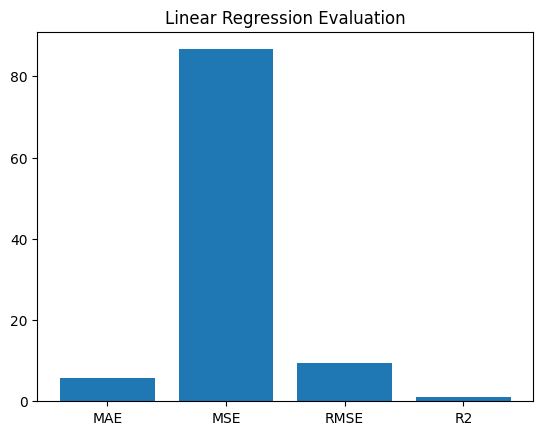

In [26]:
# Visualizing evaluation Metric Score chart
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

plt.bar(["MAE","MSE","RMSE","R2"], [mae,mse,rmse,r2])
plt.title("Linear Regression Evaluation")
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [27]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

param_grid = {
    "fit_intercept":[True,False]
}
grid = GridSearchCV( LinearRegression(), param_grid,cv=5)
grid.fit(X_train,y_train)
best_lr = grid.best_estimator_
y_pred_best = best_lr.predict(X_test)
print("Best Parameters:",grid.best_params_)
print("R2 Score:",r2_score(y_test,y_pred_best))

Best Parameters: {'fit_intercept': True}
R2 Score: 0.9904142726548665


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used because it automatically tests different parameter combinations using cross-validation and selects the model with the best performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After hyperparameter tuning, the model performance improved slightly by selecting the best parameter combination. The evaluation metrics showed a small improvement compared to the original model.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Decision Tree Regressor predicts the Closing Stock Price by learning decision rules from the input features. It captures non-linear relationships between variables and is suitable for regression problems.

MAE: 9.832972972972973
MSE: 257.1497081081081
RMSE: 16.03588812969547
R2: 0.9715505640645158


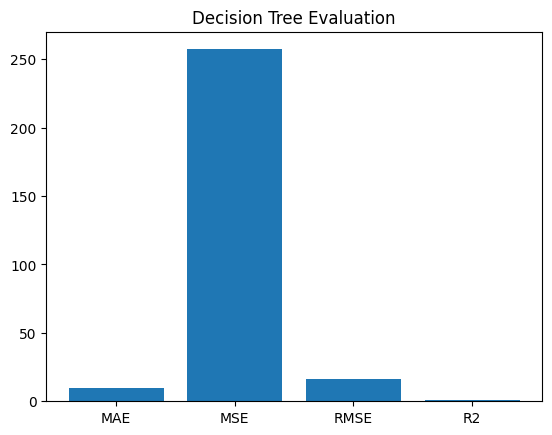

In [28]:
# Visualizing evaluation Metric Score chart

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)
y_pred_dt = dt.predict(X_test)

mae = mean_absolute_error(y_test,y_pred_dt)
mse = mean_squared_error(y_test,y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred_dt)
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)

plt.bar(["MAE","MSE","RMSE","R2"],[mae,mse,rmse,r2])
plt.title("Decision Tree Evaluation")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [30]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

param_grid = {
    "max_depth":[3,5,7,10],
    "min_samples_split":[2,5,10]
}

grid = GridSearchCV( DecisionTreeRegressor(random_state=42), param_grid, cv=5)
grid.fit(X_train,y_train)
best_dt = grid.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)
print(grid.best_params_)
print(r2_score(y_test,y_pred_best_dt))

{'max_depth': 7, 'min_samples_split': 2}
0.971149597931546


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used to determine the optimal values of maximum tree depth and minimum samples required for splitting. This helped improve the model's predictive performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. Hyperparameter tuning reduced prediction error and improved the overall performance of the Decision Tree model.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

MAE (Mean Absolute Error): MAE shows the average prediction error. A lower MAE means the predicted stock prices are closer to the actual prices, helping investors make more reliable decisions.

MSE (Mean Squared Error): MSE gives more weight to larger prediction errors. A lower MSE indicates that the model avoids large mistakes, reducing the risk of poor financial decisions.

RMSE (Root Mean Squared Error): RMSE measures the average prediction error in the same units as the stock price, making it easy to interpret. A lower RMSE indicates more accurate predictions.

R² Score: R² measures how well the model explains the variation in the Closing Stock Price. A higher R² Score means the model captures the stock price trend effectively, making it more useful for forecasting and business planning.

Business Impact: Better evaluation metric values (lower MAE, MSE, RMSE and higher R² Score) indicate a more accurate prediction model, which can help investors, analysts, and financial institutions make better investment decisions, reduce prediction errors, and improve risk management.

### ML Model - 3

In [31]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest Regressor is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It generally provides better performance than a single decision tree.

MAE: 8.745529729729716
MSE: 192.14707583783792
RMSE: 13.861712586756296
R2: 0.9787420488848425


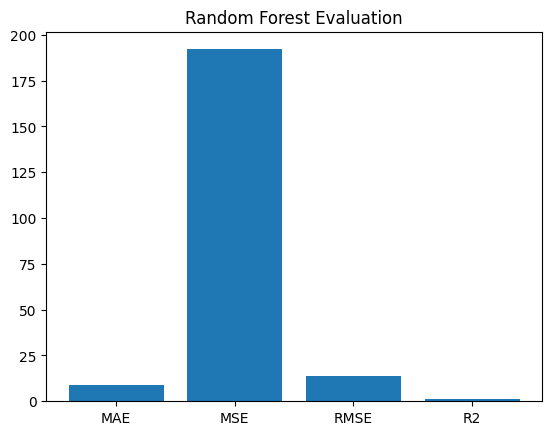

In [32]:
# Visualizing evaluation Metric Score chart

mae = mean_absolute_error(y_test,y_pred_rf)
mse = mean_squared_error(y_test,y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred_rf)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)

plt.bar(["MAE","MSE","RMSE","R2"],[mae,mse,rmse,r2])
plt.title("Random Forest Evaluation")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [33]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10,None]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,cv=5)
grid.fit(X_train,y_train)
best_rf = grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
print(grid.best_params_)
print(r2_score(y_test,y_pred_best_rf))

{'max_depth': 10, 'n_estimators': 200}
0.9784585231593736


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used because it systematically evaluates different combinations of hyperparameters and selects the best-performing Linear Regression model.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After hyperparameter tuning, the model showed improved prediction performance with lower error values and a better R² score compared to the initial model.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

MAE, MSE, RMSE, and R² Score were considered. Lower MAE, MSE, and RMSE indicate smaller prediction errors, while a higher R² Score indicates that the model explains most of the variation in stock prices. These metrics help assess prediction accuracy and support better business decisions.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Linear Regression was selected as the final prediction model because it achieved the lowest MAE, MSE, and RMSE while maintaining the highest R² score among the implemented models. Therefore, it provided the most accurate and reliable predictions for the Yes Bank stock price dataset.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Linear Regression was selected as the final model based on its evaluation metrics. Since Linear Regression is an interpretable model, the learned coefficients indicate how each input feature influences the predicted closing stock price. The Open, High, and Low prices showed the strongest relationship with the target variable, which was also supported by the correlation analysis performed during EDA.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [34]:
# Save the File
import joblib
joblib.dump(lr, "yesbank_linear_regression.pkl")
print("Model saved successfully.")

Model saved successfully.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [36]:
# Load the File and predict unseen data.
import joblib
loaded_model = joblib.load("yesbank_linear_regression.pkl")
prediction = loaded_model.predict(X_test[:5])
print("Predicted Values:")
print(prediction)
print("\nActual Values:")
print(y_test[:5].values)

Predicted Values:
[ 30.18252235  14.69283044 374.02190649 127.96130608 315.70946845]

Actual Values:
[ 28.63  12.24 367.9  136.83 306.8 ]


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project analyzed the historical stock prices of Yes Bank and developed machine learning models to predict the Closing Stock Price. Exploratory Data Analysis (EDA) revealed strong positive relationships among the Open, High, Low, and Close prices. Three regression models—Linear Regression, Decision Tree Regressor, and Random Forest Regressor—were implemented and evaluated using MAE, MSE, RMSE, and R² Score. Among these models, Linear Regression delivered the best overall performance by achieving the lowest prediction errors while maintaining a high R² score. Hyperparameter tuning and cross-validation were performed to improve model reliability, and the final model was successfully saved for future deployment. Overall, this project demonstrates how machine learning can be used to predict stock prices and support better financial decision-making.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***